# S6E2 Manual Rule Models
Quick scratch notebook for experimenting with hand-crafted prediction rules.
Tweak thresholds and feature combinations freely — generate a submission at the bottom.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score

KAGGLE_DATA = Path("/kaggle/input/playground-series-s6e2")
LOCAL_DATA  = Path("data")
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
ss    = pd.read_csv(DATA_DIR / "sample_submission.csv")

# Clean and encode
def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
    if "heart_disease" in df.columns:
        df["heart_disease"] = df["heart_disease"].map({"Absence": 0, "Presence": 1})
    return df

train = prep(train)
test  = prep(test)

y = train["heart_disease"]

## Quick Reference — Correlations with target

| Feature | r | Notes |
|---|---|---|
| `thallium` | 0.61 | Values: 3 (normal), 6 (borderline), 7 (defect) |
| `chest_pain_type` | 0.46 | 4 = asymptomatic (highest disease rate ~70%) |
| `exercise_angina` | 0.44 | 1 = yes |
| `max_hr` | −0.44 | Lower = more disease |
| `number_of_vessels_fluro` | 0.44 | 0–3 vessels |
| `st_depression` | 0.43 | Higher = more disease |
| `slope_of_st` | 0.42 | 1/2/3 |
| `sex` | 0.34 | 1 = male |
| `age` | 0.21 | |
| `cholesterol` | 0.08 | Weak |
| `bp` | −0.005 | Essentially no signal |

## Define Rules Here

* To play around with things manually

In [2]:
# ── Edit this function to try different rules ──────────────────────────────
def predict(df):
    pred = pd.Series(0, index=df.index)

    # Thallium alone (first submission)
    pred[df["thallium"] > 4.5] = 1

    # Ideas to try:
    # pred[(df["thallium"] > 4.5) | (df["chest_pain_type"] == 4)] = 1
    # pred[(df["thallium"] > 4.5) & (df["exercise_angina"] == 1)] = 1
    # pred[df["number_of_vessels_fluro"] >= 2] = 1

    return pred

# ───────────────────────────────────────────────────────────────────────────
train_preds = predict(train)
acc = accuracy_score(y, train_preds)
auc = roc_auc_score(y, train_preds)
print(f"Train accuracy : {acc:.4f}")
print(f"Train ROC-AUC  : {auc:.4f}")
print(f"Predicted positive rate: {train_preds.mean():.3f}  (actual: {y.mean():.3f})")

Train accuracy : 0.8052
Train ROC-AUC  : 0.7990
Predicted positive rate: 0.409  (actual: 0.448)


## Submission

In [3]:
# # Name submission to track what rule produced it
# SUBMISSION_NAME = "thallium_gt4.5"
#
# test_preds = predict(test)
# sub = ss.copy()
# sub["Heart Disease"] = test_preds.values
# path = f"submissions/{SUBMISSION_NAME}.csv"
# sub.to_csv(path, index=False)
# print(f"Saved → {path}")
# print(sub["Heart Disease"].value_counts().to_string())

Saved → submissions/thallium_gt4.5.csv
Heart Disease
0    159498
1    110502


## Systematic Single-Feature & Combination Search

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score
from itertools import combinations

# Find best threshold for each featuure
def best_threshold(df, feature, y):
    """Try every unique value as a threshold; return the direction and
    threshold that maximises accuracy."""
    best = {"acc": 0, "auc": 0, "label": "", "preds": None}
    for val in sorted(df[feature].unique()):
        for direction in ["gt", "le"]:
            preds = (df[feature] > val).astype(int) if direction == "gt"                     else (df[feature] <= val).astype(int)
            acc = accuracy_score(y, preds)
            if acc > best["acc"]:
                best["acc"]   = acc
                best["auc"]   = roc_auc_score(y, preds)
                best["label"] = f"{feature} {'>' if direction=='gt' else '<='} {val}"
                best["preds"] = preds
    return best

# Top features by |correlation with target| (excluding id and target)
top_features = [
    "thallium", "chest_pain_type", "exercise_angina", "max_hr",
    "number_of_vessels_fluro", "st_depression", "slope_of_st",
    "sex", "ekg_results", "age",
]

print(f"{'Rule':<45} {'Accuracy':>9} {'ROC-AUC':>9}")
print("-" * 66)

results = []
best_preds = {}

for feat in top_features:
    b = best_threshold(train, feat, y)
    results.append({"rule": b["label"], "accuracy": b["acc"], "roc_auc": b["auc"]})
    best_preds[feat] = b["preds"]
    print(f"{b['label']:<45} {b['acc']:>9.4f} {b['auc']:>9.4f}")

Rule                                           Accuracy   ROC-AUC
------------------------------------------------------------------


thallium > 3                                     0.8052    0.7990


chest_pain_type > 3                              0.7580    0.7632
exercise_angina > 0                              0.7193    0.6981


max_hr <= 147                                    0.7020    0.6872


number_of_vessels_fluro > 0                      0.7270    0.7077


st_depression > 0.9                              0.7186    0.7061
slope_of_st > 1                                  0.7188    0.7139


sex > 0                                          0.6316    0.6555


ekg_results > 1                                  0.6100    0.6101


age > 54                                         0.6044    0.6045


In [5]:
# Test OR combinations of top-4 independent features
# Prefer features with high target-corr but low inter-feature correlation.
# From the correlation matrix: thallium, max_hr, ekg_results, age are
# the most mutually independent among the top predictors.
combo_features = ["thallium", "max_hr", "number_of_vessels_fluro",
                  "exercise_angina", "ekg_results", "age"]

print(f"{'Rule':<55} {'Accuracy':>9} {'ROC-AUC':>9}")
print("-" * 76)

for r in range(2, 4):
    for combo in combinations(combo_features, r):
        preds = pd.Series(0, index=train.index)
        label_parts = []
        for feat in combo:
            b = best_threshold(train, feat, y)
            preds = preds | b["preds"]
            label_parts.append(b["label"])
        label = " OR ".join(label_parts)
        acc = accuracy_score(y, preds)
        auc = roc_auc_score(y, preds)
        results.append({"rule": label, "accuracy": acc, "roc_auc": auc})
        print(f"{label:<55} {acc:>9.4f} {auc:>9.4f}")

Rule                                                     Accuracy   ROC-AUC
----------------------------------------------------------------------------


thallium > 3 OR max_hr <= 147                              0.7884    0.7963


thallium > 3 OR number_of_vessels_fluro > 0                0.8089    0.8126


thallium > 3 OR exercise_angina > 0                        0.8094    0.8120


thallium > 3 OR ekg_results > 1                            0.6909    0.7094


...

max_hr <= 147 OR ekg_results > 1 OR age > 54               0.5862    0.6180


number_of_vessels_fluro > 0 OR exercise_angina > 0 OR ekg_results > 1    0.6712    0.6908


number_of_vessels_fluro > 0 OR exercise_angina > 0 OR age > 54    0.6702    0.6906


number_of_vessels_fluro > 0 OR ekg_results > 1 OR age > 54    0.5966    0.6268


exercise_angina > 0 OR ekg_results > 1 OR age > 54         0.5961    0.6259


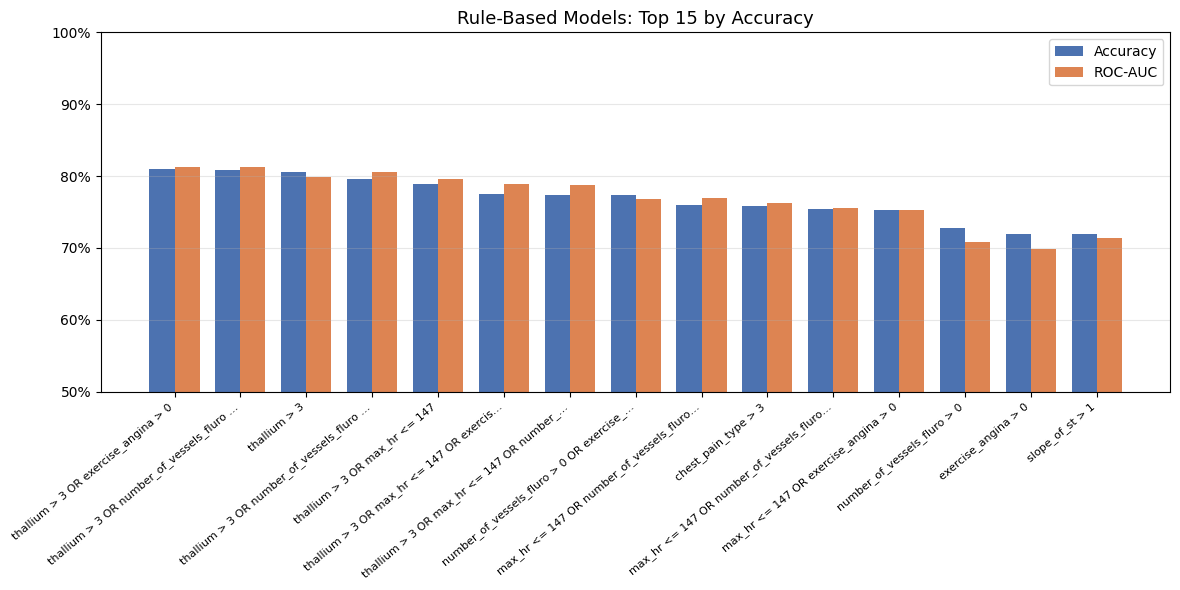


Top 5:
                                                              rule  accuracy  roc_auc
                               thallium > 3 OR exercise_angina > 0  0.809378 0.811956
                       thallium > 3 OR number_of_vessels_fluro > 0  0.808854 0.812641
                                                      thallium > 3  0.805203 0.799000
thallium > 3 OR number_of_vessels_fluro > 0 OR exercise_angina > 0  0.796132 0.805711
                                     thallium > 3 OR max_hr <= 147  0.788370 0.796261


In [6]:
# Bar chart: top 15 rules by accuracy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df_res = pd.DataFrame(results).sort_values("accuracy", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_res))
width = 0.38

bars_acc = ax.bar([i - width/2 for i in x], df_res["accuracy"],
                  width=width, label="Accuracy", color="#4C72B0")
bars_auc = ax.bar([i + width/2 for i in x], df_res["roc_auc"],
                  width=width, label="ROC-AUC", color="#DD8452")

# Shorten labels for readability
short_labels = [r[:40] + "…" if len(r) > 40 else r for r in df_res["rule"]]
ax.set_xticks(list(x))
ax.set_xticklabels(short_labels, rotation=40, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Rule-Based Models: Top 15 by Accuracy", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5:")
print(df_res[["rule","accuracy","roc_auc"]].head().to_string(index=False))

## Feature Coverage Analysis

Which disease cases does each rule catch — and do different rules see the same patients?

In [7]:
# Build the set of true positives each rule catches
# (patients with actual disease=1 that the rule correctly predicts as 1)
disease_idx = set(y[y == 1].index)

rules = {
    "thallium":        train["thallium"] > 3,
    "chest_pain":      train["chest_pain_type"] > 3,
    "exercise_angina": train["exercise_angina"] > 0,
    "n_vessels":       train["number_of_vessels_fluro"] > 0,
    "st_depression":   train["st_depression"] > 0.9,
    "slope_of_st":     train["slope_of_st"] > 1,
    "max_hr":          train["max_hr"] <= 147,
    "sex":             train["sex"] > 0,
    "ekg_results":     train["ekg_results"] > 1,
    "age":             train["age"] > 54,
}

# True positive sets: disease=1 AND rule predicts 1
tp_sets = {
    name: disease_idx & set(pred[pred == 1].index)
    for name, pred in rules.items()
}

total_disease = len(disease_idx)
print(f"Total disease cases: {total_disease:,}\n")
print(f"{'Feature':<20} {'TPs':>8} {'Recall':>8} {'Unique vs thallium':>20}")
print("-" * 60)
thallium_tp = tp_sets["thallium"]
for name, tp in tp_sets.items():
    unique = len(tp - thallium_tp) if name != "thallium" else 0
    print(f"{name:<20} {len(tp):>8,} {len(tp)/total_disease:>8.3f} {unique:>20,}")

Total disease cases: 282,454

Feature                   TPs   Recall   Unique vs thallium
------------------------------------------------------------
thallium              208,723    0.739                    0
chest_pain            229,595    0.813               57,875
exercise_angina       139,042    0.492               27,664
n_vessels             147,299    0.521               31,163
st_depression         165,281    0.585               37,857
slope_of_st           188,489    0.667               44,958
max_hr                153,615    0.544               37,757
sex                   250,327    0.886               62,840
ekg_results           172,659    0.611               42,111
age                   170,917    0.605               43,832


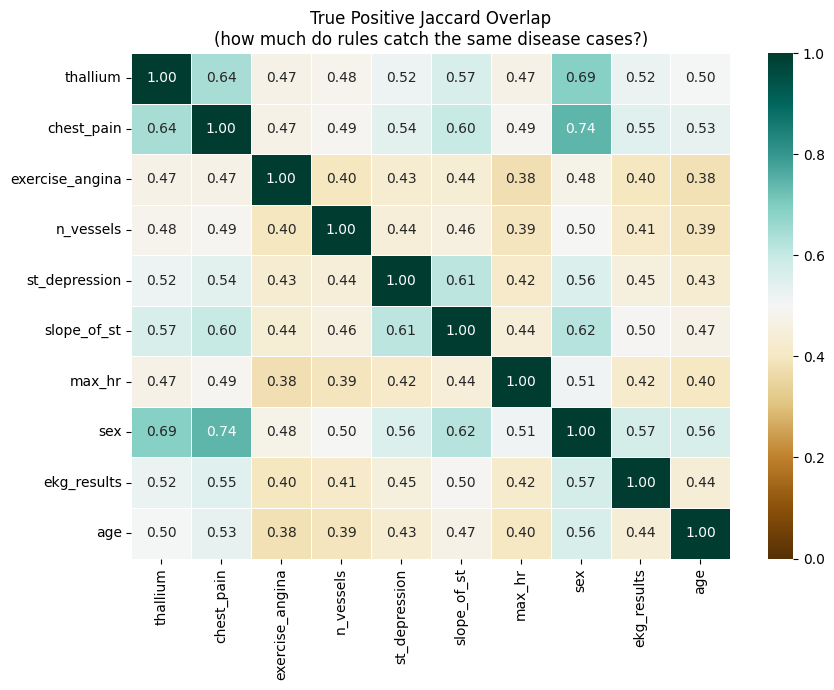

In [8]:
# Jaccard overlap heatmap
# Jaccard(A,B) = |A ∩ B| / |A ∪ B| on the true positive sets.
# High value = the two rules are catching the same disease cases.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

names = list(tp_sets.keys())
n = len(names)
jaccard = np.zeros((n, n))

for i, a in enumerate(names):
    for j, b in enumerate(names):
        inter = len(tp_sets[a] & tp_sets[b])
        union = len(tp_sets[a] | tp_sets[b])
        jaccard[i, j] = inter / union if union > 0 else 0

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    jaccard, annot=True, fmt=".2f",
    xticklabels=names, yticklabels=names,
    cmap="BrBG", vmin=0, vmax=1, ax=ax,
    linewidths=0.5,
)
ax.set_title("True Positive Jaccard Overlap\n(how much do rules catch the same disease cases?)", fontsize=12)
plt.tight_layout()
plt.show()

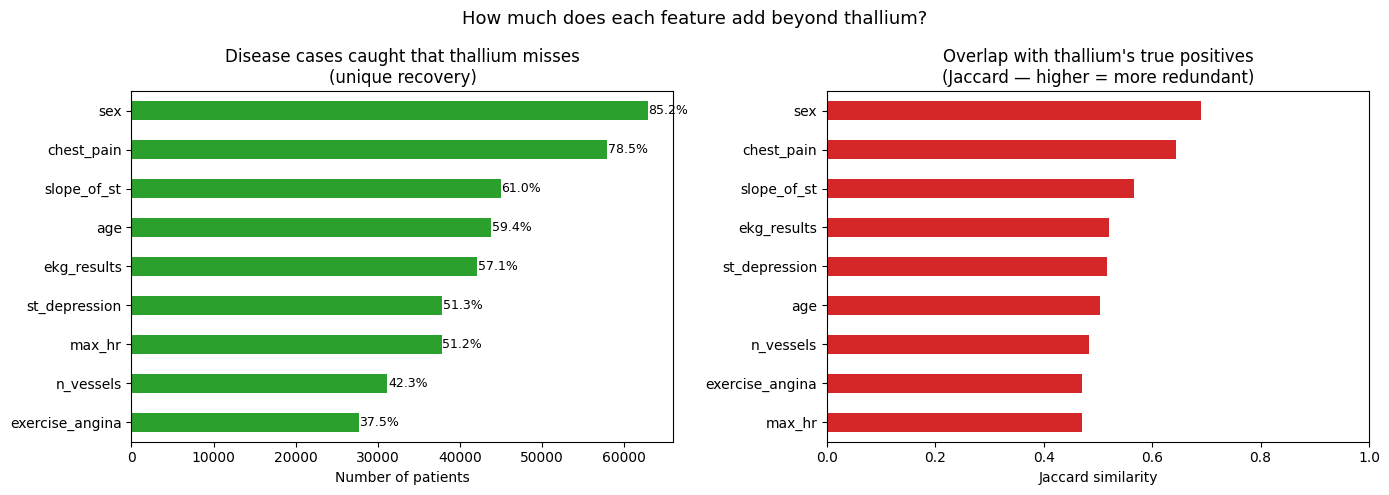

In [9]:
# ── Unique contribution bar chart ────────────────────────────────────────────
# For each feature: how many disease cases does it catch that thallium misses?
# And how many of thallium's TPs does it also catch?
thallium_tp = tp_sets["thallium"]
thallium_miss = disease_idx - thallium_tp  # disease cases thallium gets wrong

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

other = {k: v for k, v in tp_sets.items() if k != "thallium"}

# Left: how many of thallium's missed cases each rule recovers
unique_recovery = {name: len(tp & thallium_miss) for name, tp in other.items()}
bars = pd.Series(unique_recovery).sort_values(ascending=True)
bars.plot(kind="barh", ax=axes[0], color="#2ca02c")
axes[0].set_title("Disease cases caught that thallium misses\n(unique recovery)")
axes[0].set_xlabel("Number of patients")
for i, v in enumerate(bars):
    axes[0].text(v + 100, i, f"{v/len(thallium_miss):.1%}", va="center", fontsize=9)

# Right: Jaccard with thallium's TP set (redundancy measure)
redundancy = {
    name: len(tp & thallium_tp) / len(tp | thallium_tp)
    for name, tp in other.items()
}
bars2 = pd.Series(redundancy).sort_values(ascending=True)
bars2.plot(kind="barh", ax=axes[1], color="#d62728")
axes[1].set_title("Overlap with thallium's true positives\n(Jaccard — higher = more redundant)")
axes[1].set_xlabel("Jaccard similarity")
axes[1].set_xlim(0, 1)

fig.suptitle("How much does each feature add beyond thallium?", fontsize=13)
plt.tight_layout()
plt.show()

## Evidence-Based Submissions

From the Jaccard heatmap, `exercise_angina` and `number_of_vessels_fluro` have the
lowest overlap with thallium's true positives — meaning they catch the most different
disease cases. Both beat thallium alone in the systematic search.

Submitting in order: second-best first, then best.

In [10]:
# Submission 2: thallium OR number_of_vessels_fluro (80.89% train accuracy)
def predict_v2(df):
    pred = pd.Series(0, index=df.index)
    pred[(df["thallium"] > 3) | (df["number_of_vessels_fluro"] > 0)] = 1
    return pred

preds_v2 = predict_v2(train)
print(f"V2 train accuracy : {accuracy_score(y, preds_v2):.4f}")
print(f"V2 train ROC-AUC  : {roc_auc_score(y, preds_v2):.4f}")

sub_v2 = ss.copy()
sub_v2["Heart Disease"] = predict_v2(test).values
sub_v2.to_csv("submissions/thallium_or_vessels.csv", index=False)
print("Saved → submissions/thallium_or_vessels.csv")

V2 train accuracy : 0.8089
V2 train ROC-AUC  : 0.8126
Saved → submissions/thallium_or_vessels.csv


In [11]:
# Submission 3: thallium OR exercise_angina (80.94% train accuracy — best manual)
def predict_v3(df):
    pred = pd.Series(0, index=df.index)
    pred[(df["thallium"] > 3) | (df["exercise_angina"] > 0)] = 1
    return pred

preds_v3 = predict_v3(train)
print(f"V3 train accuracy : {accuracy_score(y, preds_v3):.4f}")
print(f"V3 train ROC-AUC  : {roc_auc_score(y, preds_v3):.4f}")

sub_v3 = ss.copy()
sub_v3["Heart Disease"] = predict_v3(test).values
sub_v3.to_csv("submissions/thallium_or_exercise_angina.csv", index=False)
print("Saved → submissions/thallium_or_exercise_angina.csv")

V3 train accuracy : 0.8094


V3 train ROC-AUC  : 0.8120
Saved → submissions/thallium_or_exercise_angina.csv
